# Expense analyzer — findings

**Fill this cell in last, and present only this cell.**

1. _`<Category>` is Rs `<x>`/month, `<y>`% of spend._
2. _`<z>`% of `<category>` spending happens at weekends._
3. _Spend rose `<n>`% from `<month>` to `<month>`, driven by `<category>`._
4. _Median transaction is Rs `<m>` — bled by frequency, not size._
5. _Savings rate is `<a>`%; cutting `<category>` would take it to `<b>`%._

**What did not work:** _`<the rule that misfired, and why>`_

In [1]:
%load_ext autoreload
%autoreload 2



import pandas as pd

from expense_analyzer import analyze, categorize
from expense_analyzer.clean import load_and_clean

pd.set_option("display.max_colwidth", 60)

## 1. Load and clean

Look at the raw frame before trusting anything: `dtypes` shows the amount
columns arrive as `object` (text), not numbers.

In [2]:
frame = load_and_clean("data/sample_statement.csv")
print(frame.shape)
frame.head()

(180, 6)


,date,month,day_name,is_weekend,narration,amount
0,2026-05-01,2026-05,Friday,False,UPI-BIGBASKET-bbdaily@icici-472731,-858.45
1,2026-05-01,2026-05,Friday,False,UPI-9876543210@ybl-PAYMENT FROM PHONE-717740,-365.23
2,2026-05-01,2026-05,Friday,False,NEFT-ACME SOFTWARE PVT LTD-SALARY CREDIT,46000.00
3,2026-05-02,2026-05,Saturday,True,UPI-SWIGGY-swiggy@icici-661913-ORDER,-184.05
4,2026-05-02,2026-05,Saturday,True,UPI-SWIGGY-swiggy@icici-229815-ORDER,-538.62


## 2. Categorize, then check coverage

Read the unmatched narrations, add keywords to `CATEGORY_RULES`, re-run.
Repeat until uncategorised is under 5% **by value**.

In [3]:
frame = categorize.add_categories(frame)
categorize.coverage(frame)

{'rows_total': 180.0,
 'rows_uncategorized': 23.0,
 'pct_rows_uncategorized': 12.8,
 'value_uncategorized': np.float64(11584.35),
 'pct_value_uncategorized': np.float64(4.6)}

In [4]:
categorize.unmatched_narrations(frame)

,charges,total
merchant,,
NEFT-UTIB-TRF,6,6750.48
POS XXXX IN*RAZ*ORDERS,3,1832.38
UPI-@YBL-PAYMENT FROM PHONE,6,1663.85
UPI-BHARATPE-MERCHANT PAY,8,1337.64


## 3. Aggregate

In [5]:
spend = analyze.spending_only(frame)

print(analyze.by_category(spend).round(0))
print()
print(analyze.monthly_totals(spend).round(0))
print()
print(f"savings rate: {analyze.savings_rate(frame):.1%}")
print(f"median transaction: {spend['amount'].median():,.0f}")

category
Rent             25500.0
Food             20734.0
Shopping         15866.0
Groceries        13825.0
Transport        12068.0
Uncategorized    11584.0
Bills             7914.0
Subscriptions     5904.0
Name: amount, dtype: float64

month
2026-05    39534.0
2026-06    36097.0
2026-07    37764.0
Freq: M, Name: amount, dtype: float64

savings rate: 18.0%
median transaction: 388


In [6]:
analyze.recurring_candidates(spend)

,months,charges,mean_amount,min_amount,max_amount,annual_cost
merchant,,,,,,
UPI-SANDEEP PATIL-SANDEEP@OKSBI-HOUSE RENT,3,3,8500.0,8500.0,8500.0,102000.0
BILLPAY MSEDCL ELECTRICITY MAHARASHTRA,3,3,1460.0,1460.0,1460.0,17520.0
UPI-CULT FITNESS GYM-CULTFIT@YBL-AUTOPAY,3,3,1200.0,1200.0,1200.0,14400.0
UPI-ACT FIBERNET BROADBAND-ACT@ICICI,3,3,799.0,799.0,799.0,9588.0
UPI-NETFLIX ENTERTAINMENT-NETFLIX@HDFCBANK-AUTOPAY,3,3,649.0,649.0,649.0,7788.0
UPI-AIRTEL PREPAID-AIRTEL@AXISBANK-RECHARGE,3,3,379.0,379.0,379.0,4548.0
UPI-SPOTIFY INDIA-SPOTIFY@ICICI-AUTOPAY,3,3,119.0,119.0,119.0,1428.0


## 4. Charts

Inline here; `run.py` writes the same four to `reports/`.

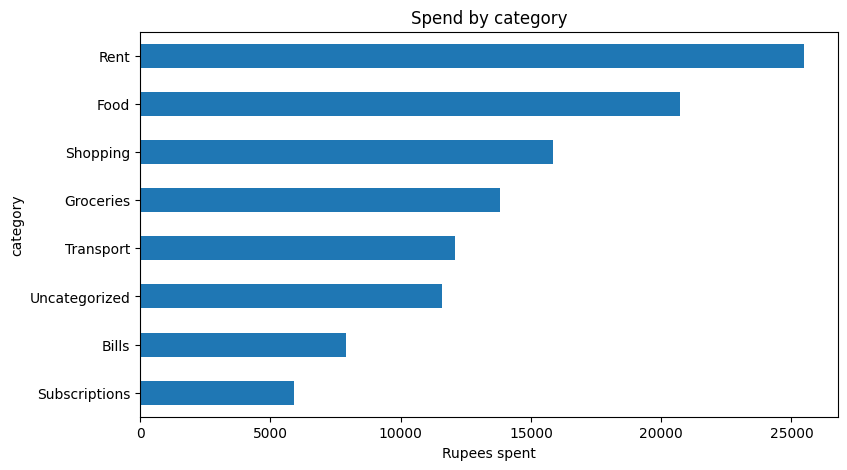

In [7]:
%matplotlib inline

analyze.by_category(spend).sort_values().plot.barh(
    figsize=(9, 5), xlabel="Rupees spent", title="Spend by category"
);

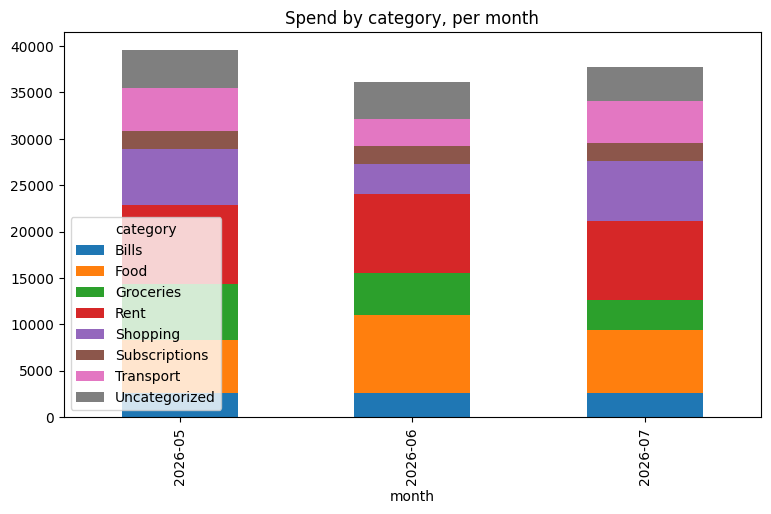

In [8]:
analyze.category_by_month(spend).plot.bar(
    stacked=True, figsize=(9, 5), title="Spend by category, per month"
);

## 5. Weekend vs weekday

Statements have no clock time, so day-of-week is the finest time signal
available. Hour-of-day analysis is not possible from this data.

33% of food spending falls at the weekend


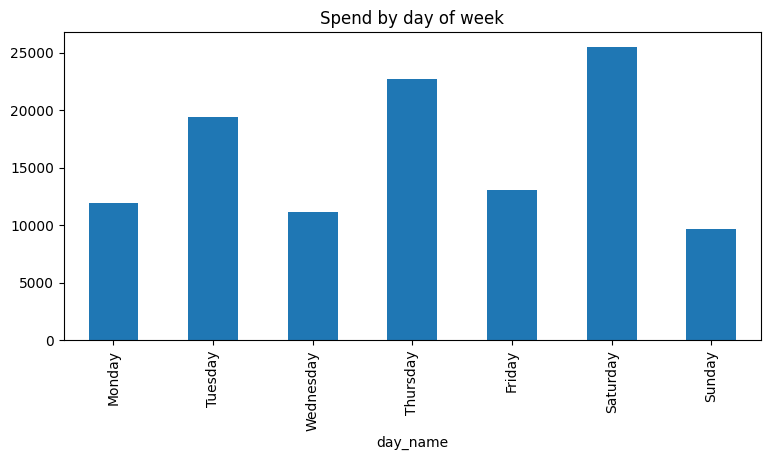

In [9]:
food = spend[spend["category"] == "Food"]
share = food[food["is_weekend"]]["amount"].sum() / food["amount"].sum()
print(f"{share:.0%} of food spending falls at the weekend")

analyze.weekday_split(spend).plot.bar(figsize=(9, 4), title="Spend by day of week");